# Ensemble on `benchset_v1_large_set_a.parquet` combined with `papers_fe.parquet` — stacking CatBoost + LogReg + RandomForest

**Author:** SF — **Branch:** `new-dataset-experiments` — **Status:** executed, with real
results (see §1's cached run). Same stacking architecture as `08_ensemble_pooled.ipynb`
(CatBoost + LogisticRegression + RandomForest, combined by a `LogisticRegression` meta-learner
on leakage-safe out-of-fold predictions), trained on a combined pool: this notebook's training
pool is `benchset_v1_large_set_a.parquet`'s rows **concatenated** with `papers_fe.parquet`'s
rows — the original TIRI corpus is folded INTO training here, rather than held out as a
separate test surface.

**Companion notebook:** `sf_ensemble_benchset_v1_large_set_b_plus_papers_fe.ipynb` — identical in every respect except it combines
`benchset_v1_large_set_b.parquet` with `papers_fe.parquet` instead. Read either one first; they share every
design decision below.

## What's frozen, and why

Per the project owner's direction, **no hyperparameter search happens in this notebook.**
Every hyperparameter — `RF_PARAMS`, `CB_PARAMS`, `META_C`, `DECISION_THRESHOLD` — is imported
directly from `scripts/modal_benchset_v1_ensemble.py`, the same frozen values
`08_ensemble_pooled.ipynb` and `10_logo_ensemble.ipynb` both use unchanged.

## Training-set design

The project owner posed this question explicitly: **does folding the original TIRI corpus
into the training pool itself help the model generalize to genuinely new, disjoint
published-review collections** — measured on `benchset_v1_small_test.parquet`, the one file
neither half of this notebook's training data has ever touched?

**Confirmed with the project owner, not assumed:**
- **No outer holdout in this design.** The final ensemble is refit on 100% of the combined
  training pool (`benchset_v1_large_set_a.parquet` + `papers_fe.parquet`, concatenated). Fold validation — a
  single `StratifiedGroupKFold(5)` (grouped by `first_author`, stratified on
  `use_case_key + y`) over the **entire** combined pool — is the only in-sample check; there
  is no separate "holdout" stage the way the pooled-split notebooks have one.
  `benchset_v1_small_test.parquet` is the only test-stage score this notebook reports.
- **F2, AUC, recall, and precision are reported together at every metrics table**, per the
  project owner's explicit instruction.

## Feature columns: the common intersection

`08_ensemble_pooled.ipynb`'s frozen feature list includes `cos_brief_qwen8b`,
`rank_cos_brief_qwen8b`, `has_abstract`, and `lex_has_exclude_terms` — none of which exist in
`benchset_v1_*.parquet`. Conversely, `benchset_v1_*.parquet` carries
`cos_briefpre_*`/`rank_cos_briefpre_*` columns `papers_fe.parquet` doesn't have. Both
non-overlapping groups stay excluded here too — see `scripts/modal_benchset_v1_ensemble.py`'s
module docstring for the exact resulting 29-column non-embedding list, identical to the
sibling notebook.

## Why Modal

The combined training pool is `benchset_v1_large_set_a.parquet`'s tens of thousands of rows plus
`papers_fe.parquet`'s 1,848 — one to two orders of magnitude past what this project fits
locally without issue (`CONTEXT.md` §7). All of this notebook's model fitting happens in
`scripts/modal_benchset_v1_ensemble.py::run_ensemble_combined`, on a dedicated Modal app
(`tiri-benchset-v1-ensemble`) and volume (`tiri-benchset-v1-data`) — no new setup needed if
those are already deployed/uploaded (see that script's module docstring for the exact setup
steps).

## Structure

(1) load the frozen hyperparameters and fetch (or fit, on first run) the ensemble via Modal;
(2) hyperparameter catalog and combined-pool composition; (3) does stacking actually help on
this combined corpus — branch-level vs. meta-level out-of-fold quality; (4) train → validation
(fold), F2/AUC/recall/precision side by side — no holdout stage; (5) hypothesis tests on the
validation-level out-of-fold predictions (paired bootstrap — every row's prediction already
comes from a model that never saw that row, so this is exactly as leakage-safe as testing on a
held-out surface); (6) the test surface — `benchset_v1_small_test.parquet`; (7) side-by-side
comparison table and plot — validation vs. test; (8) hard findings; (9) scope & limitations.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## Parameters

`TRAIN_FILE` is the file combined with `papers_fe.parquet` to build this notebook's training
pool; `MODAL_FUNCTION_NAME` points at `run_ensemble_combined`, the Modal function this design
uses. Every hyperparameter is imported from `scripts/modal_benchset_v1_ensemble.py` — the
single source of truth every notebook in this line reads from. `CACHE_PATH` gets its own
`_plus_papers_fe` suffix so this notebook's cache never collides with its sibling's.

In [2]:
SCRIPTS_DIR = Path("../../scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

from modal_benchset_v1_ensemble import (
    APP_NAME as MODAL_APP_NAME,
    CB_PARAMS,
    DECISION_THRESHOLD,
    META_C,
    NON_EMBEDDING_FEATURE_COLS,
    PAPERS_FE_FILENAME,
    PCA_N_COMPONENTS,
    RF_PARAMS,
    SMALL_TEST_FILENAME,
)

MODAL_FUNCTION_NAME = "run_ensemble_combined"
TRAIN_FILE = "benchset_v1_large_set_a.parquet"

REPORTS_DIR = Path("../../reports").resolve()
CACHE_PATH = REPORTS_DIR / f"sf_ensemble_{Path(TRAIN_FILE).stem}_plus_papers_fe.json"
FORCE_REFIT = False  # set True to force a fresh (paid) Modal run even if a cached result exists

N_BOOT = 2000       # bootstrap resamples for every hypothesis test below
ALPHA = 0.05
RANDOM_STATE = 0

print(f"Frozen hyperparameters (imported from scripts/modal_benchset_v1_ensemble.py, not re-tuned here):")
for name, val in [("RF_PARAMS", RF_PARAMS), ("CB_PARAMS", CB_PARAMS), ("META_C", META_C),
                   ("DECISION_THRESHOLD", DECISION_THRESHOLD), ("PCA_N_COMPONENTS", PCA_N_COMPONENTS),
                   ("n_non_embedding_features", len(NON_EMBEDDING_FEATURE_COLS))]:
    print(f"  {name}: {val}")
print(f"\nTraining pool: {TRAIN_FILE} + {PAPERS_FE_FILENAME} (concatenated) | Test surface: {SMALL_TEST_FILENAME}")


Frozen hyperparameters (imported from scripts/modal_benchset_v1_ensemble.py, not re-tuned here):
  RF_PARAMS: {'n_estimators': 527, 'max_depth': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}
  CB_PARAMS: {'depth': 6, 'learning_rate': 0.06119889729184578, 'l2_leaf_reg': 7.474245667651606, 'iterations': 656}
  META_C: 0.1
  DECISION_THRESHOLD: 0.2
  PCA_N_COMPONENTS: 50
  n_non_embedding_features: 29

Training pool: benchset_v1_large_set_a.parquet + papers_fe.parquet (concatenated) | Test surface: benchset_v1_small_test.parquet


## 1. Fetch (or fit, on first run) the combined-training ensemble via Modal

If `CACHE_PATH` already holds a result from a prior run and `FORCE_REFIT` is `False`, it's
loaded straight from disk — no Modal call, no cost. Otherwise this calls
`scripts/modal_benchset_v1_ensemble.py::run_ensemble_combined` remotely, which must already be
deployed (`modal deploy scripts/modal_benchset_v1_ensemble.py`) with the four parquet files it
needs already uploaded to the `tiri-benchset-v1-data` volume
(`modal run scripts/modal_benchset_v1_ensemble.py::upload_data`) — the same setup the sibling
notebooks share; nothing new to upload if that's already been done. **This is the one cell in
this notebook that spends Modal compute credits on a fresh run** — everything below only reads
`result`.


In [3]:
if CACHE_PATH.exists() and not FORCE_REFIT:
    print(f"Loading cached result from {CACHE_PATH} (FORCE_REFIT=False) ...")
    result = json.loads(CACHE_PATH.read_text(encoding="utf-8"))
else:
    import modal

    print(f"No cache found (or FORCE_REFIT=True) - calling {MODAL_APP_NAME}::{MODAL_FUNCTION_NAME}.remote({TRAIN_FILE!r}) ...")
    print("This requires `modal deploy scripts/modal_benchset_v1_ensemble.py` and "
          "`modal run scripts/modal_benchset_v1_ensemble.py::upload_data` to have already run.")
    fn = modal.Function.from_name(MODAL_APP_NAME, MODAL_FUNCTION_NAME)
    result = fn.remote(TRAIN_FILE)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    CACHE_PATH.write_text(json.dumps(result), encoding="utf-8")
    print(f"Done. Cached to {CACHE_PATH}.")

# Arrays the Modal side returns as plain lists (JSON-safe) - convert once, up front.
y_validation = np.array(result["y_validation"])
meta_oof_proba = np.array(result["meta_oof_proba"])
branch_oof_proba = {name: np.array(arr) for name, arr in result["branch_oof_proba"].items()}

test = result["test"]
test["y"] = np.array(test["y"])
test["proba"] = np.array(test["proba"])
for name in test["branch_proba"]:
    test["branch_proba"][name] = np.array(test["branch_proba"][name])

print(f"\nCombined training pool: {result['n_total']:,} rows "
      f"({result['n_from_train_file']:,} from {result['train_filename']} + "
      f"{result['n_from_papers_fe']:,} from {result['combined_with']})")
print(f"{len(result['use_cases'])} use cases total: {', '.join(result['use_cases'])}")
print(f"{result['n_features']:,} feature columns ({result['n_embedding_cols']:,} embedding + "
      f"{result['n_features'] - result['n_embedding_cols']} non-embedding)")
print(f"Test surface ({result['test_filename']}): {test['n']:,} rows, pos_rate={test['pos_rate']:.4f}")


Loading cached result from C:\Users\fossi\Desktop\Bootcamp\TIRI---The-Data-science-project\reports\sf_ensemble_benchset_v1_large_set_a_plus_papers_fe.json (FORCE_REFIT=False) ...



Combined training pool: 64,077 rows (62,229 from benchset_v1_large_set_a.parquet + 1,848 from papers_fe.parquet)
14 use cases total: carbon_capture, cement_binders, ner, soil_microbiome, solar_leo, synergy_brouwer_2019, synergy_leenaars_2020, synergy_moran_2021, synergy_muthu_2021, synergy_nelson_2002, synergy_sep_2021, synergy_van_der_valk_2021, synergy_van_dis_2020, tech_forecasting
4,637 feature columns (4,608 embedding + 29 non-embedding)
Test surface (benchset_v1_small_test.parquet): 30,740 rows, pos_rate=0.0116


## 2. Hyperparameter catalog and combined-pool composition

Every value here was fixed before this notebook ran — nothing below this cell chooses or
searches over any of them.


In [4]:
hyperparam_catalog = pd.DataFrame([
    {"model": "RandomForest", "hyperparameter": "n_estimators", "final_value": RF_PARAMS["n_estimators"], "source": "08_ensemble_pooled.ipynb §5 (Bayesian/Optuna, not re-run here)"},
    {"model": "RandomForest", "hyperparameter": "max_depth", "final_value": RF_PARAMS["max_depth"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "RandomForest", "hyperparameter": "min_samples_leaf", "final_value": RF_PARAMS["min_samples_leaf"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "RandomForest", "hyperparameter": "max_features", "final_value": RF_PARAMS["max_features"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "CatBoost", "hyperparameter": "depth", "final_value": CB_PARAMS["depth"], "source": "08_ensemble_pooled.ipynb §5 (ensemble-role objective)"},
    {"model": "CatBoost", "hyperparameter": "learning_rate", "final_value": round(CB_PARAMS["learning_rate"], 4), "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "CatBoost", "hyperparameter": "l2_leaf_reg", "final_value": round(CB_PARAMS["l2_leaf_reg"], 3), "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "CatBoost", "hyperparameter": "iterations", "final_value": CB_PARAMS["iterations"], "source": "08_ensemble_pooled.ipynb §5"},
    {"model": "Meta-learner (LogReg)", "hyperparameter": "C", "final_value": META_C, "source": "08_ensemble_pooled.ipynb §6"},
    {"model": "Ensemble (final)", "hyperparameter": "decision_threshold", "final_value": DECISION_THRESHOLD, "source": "08_ensemble_pooled.ipynb §6"},
    {"model": "Preprocessing", "hyperparameter": "PCA_N_COMPONENTS", "final_value": PCA_N_COMPONENTS, "source": "08_ensemble_pooled.ipynb §2 (structural, not tuned)"},
])
display(hyperparam_catalog)

print(f"\nMeta-learner coefficients (higher = more trusted by the ensemble):")
display(pd.Series(result["meta_coefficients"]).sort_values(ascending=False).round(3))

composition = pd.Series({
    "n_total": result["n_total"],
    f"n_from_{Path(result['train_filename']).stem}": result["n_from_train_file"],
    "n_from_papers_fe": result["n_from_papers_fe"],
    "pct_from_papers_fe": round(100 * result["n_from_papers_fe"] / result["n_total"], 2),
})
print(f"\nCombined-pool composition (papers_fe is a small minority of the pool by row count):")
display(composition)


,model,hyperparameter,final_value,source
0,RandomForest,n_estimators,527,"08_ensemble_pooled.ipynb §5 (Bayesian/Optuna, ..."
1,RandomForest,max_depth,13,08_ensemble_pooled.ipynb §5
2,RandomForest,min_samples_leaf,7,08_ensemble_pooled.ipynb §5
3,RandomForest,max_features,sqrt,08_ensemble_pooled.ipynb §5
4,CatBoost,depth,6,08_ensemble_pooled.ipynb §5 (ensemble-role obj...
5,CatBoost,learning_rate,0.0612,08_ensemble_pooled.ipynb §5
6,CatBoost,l2_leaf_reg,7.474,08_ensemble_pooled.ipynb §5
7,CatBoost,iterations,656,08_ensemble_pooled.ipynb §5
8,Meta-learner (LogReg),C,0.1,08_ensemble_pooled.ipynb §6
9,Ensemble (final),decision_threshold,0.2,08_ensemble_pooled.ipynb §6



Meta-learner coefficients (higher = more trusted by the ensemble):


rf          4.055
catboost    2.867
logreg      1.043
dtype: float64


Combined-pool composition (papers_fe is a small minority of the pool by row count):


n_total                           64077.00
n_from_benchset_v1_large_set_a    62229.00
n_from_papers_fe                   1848.00
pct_from_papers_fe                    2.88
dtype: float64

## 3. Does stacking actually help on this combined corpus? Branch-level vs. meta-level out-of-fold quality

Same comparison `08_ensemble_pooled.ipynb` §10 makes: each base branch's own out-of-fold
predictions on the combined pool, alone, vs. the stacked meta-learner's out-of-fold
predictions on the same rows.

In [5]:
branch_oof = pd.DataFrame(result["branch_oof_metrics"]).T
meta_oof_df = pd.DataFrame(result["validation_rows"])
meta_oof_row = pd.Series(
    {"auc": meta_oof_df["auc"].mean(), "ap": meta_oof_df["ap"].mean(),
     "precision": meta_oof_df["precision"].mean(), "recall": meta_oof_df["recall"].mean(),
     "f2_at_0.5": meta_oof_df["f2_at_0.5"].mean(), "f2_at_threshold": meta_oof_df["f2_at_threshold"].mean()},
    name="meta (stacked)",
)
oof_comparison = pd.concat([branch_oof, meta_oof_row.to_frame().T]).round(3)
display(oof_comparison)

best_branch_auc = branch_oof["auc"].max()
print(f"\nMeta-learner OOF AUC ({meta_oof_row['auc']:.3f}) vs. best single branch ({best_branch_auc:.3f}): "
      f"{'stacking ahead' if meta_oof_row['auc'] > best_branch_auc else 'stacking NOT ahead of the best single branch'} "
      f"by {meta_oof_row['auc'] - best_branch_auc:+.3f} AUC (point estimate - §5 below tests this on the validation OOF).")


,auc,ap,precision,recall,f2_at_0.5,f2_at_threshold
catboost,0.976,0.689,0.256,0.966,0.698,0.622
logreg,0.963,0.592,0.159,0.965,0.607,0.479
rf,0.978,0.697,0.267,0.965,0.715,0.634
meta (stacked),0.978,0.704,0.272,0.962,0.697,0.638



Meta-learner OOF AUC (0.978) vs. best single branch (0.978): stacking ahead by +0.000 AUC (point estimate - §5 below tests this on the validation OOF).


## 4. Train → validation (fold) — F2, AUC, recall, and precision side by side

**No holdout stage in this design** (confirmed with the project owner — see the intro):
`train` is the refit-on-the-full-combined-pool ensemble scored on that same pool
(optimistic, in-sample); `validation` is the pooled inner-fold out-of-fold meta-level
predictions from the single `StratifiedGroupKFold(5)` over the entire combined pool, mean ±
std across the 5 folds. The train→validation gap is ordinary overfitting — there is no
validation→holdout gap to report here, since there is no holdout; the domain-shift question
this design asks is answered in §6/§7 against `benchset_v1_small_test.parquet` instead.
**F2, AUC, recall, and precision are reported together**, per the project owner's explicit
instruction.


,auc,recall,precision,f2_at_0.5,f2_at_threshold
train,0.995,1.000,0.289,0.755,0.671
validation_mean,0.978,0.962,0.272,0.697,0.638
validation_std,0.001,0.007,0.017,0.015,0.019


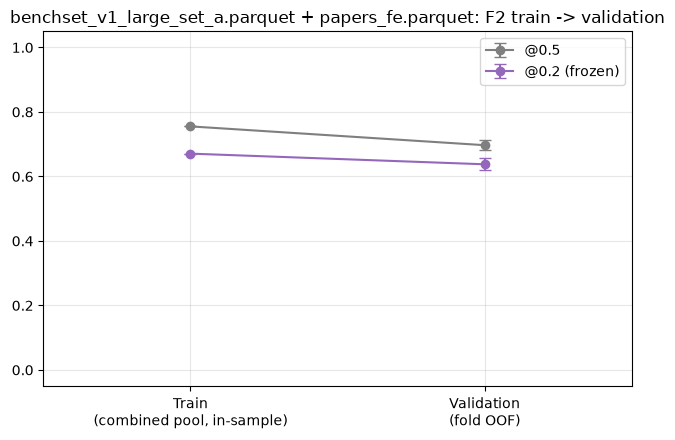

In [6]:
val_df = pd.DataFrame(result["validation_rows"])

stage_table = pd.DataFrame({
    "train": {"auc": result["train_metrics"]["auc"], "recall": result["train_metrics"]["recall"],
               "precision": result["train_metrics"]["precision"],
               "f2_at_0.5": result["train_metrics"]["f2_at_0.5"], "f2_at_threshold": result["train_metrics"]["f2_at_threshold"]},
    "validation_mean": {"auc": val_df["auc"].mean(), "recall": val_df["recall"].mean(),
                         "precision": val_df["precision"].mean(),
                         "f2_at_0.5": val_df["f2_at_0.5"].mean(), "f2_at_threshold": val_df["f2_at_threshold"].mean()},
    "validation_std": {"auc": val_df["auc"].std(), "recall": val_df["recall"].std(),
                        "precision": val_df["precision"].std(),
                        "f2_at_0.5": val_df["f2_at_0.5"].std(), "f2_at_threshold": val_df["f2_at_threshold"].std()},
}).T.round(3)
display(stage_table)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
stage_labels = ["Train\n(combined pool, in-sample)", "Validation\n(fold OOF)"]
x = range(2)

f2_05 = [result["train_metrics"]["f2_at_0.5"], val_df["f2_at_0.5"].mean()]
f2_05_err = [0, val_df["f2_at_0.5"].std()]
f2_thr = [result["train_metrics"]["f2_at_threshold"], val_df["f2_at_threshold"].mean()]
f2_thr_err = [0, val_df["f2_at_threshold"].std()]

ax.errorbar(x, f2_05, yerr=f2_05_err, marker="o", capsize=4, label="@0.5", color="tab:gray")
ax.errorbar(x, f2_thr, yerr=f2_thr_err, marker="o", capsize=4, label=f"@{DECISION_THRESHOLD} (frozen)", color="tab:purple")
ax.set_xticks(list(x)); ax.set_xticklabels(stage_labels)
ax.set_xlim(-0.5, 1.5)
ax.set_title(f"benchset_v1_large_set_a.parquet + papers_fe.parquet: F2 train -> validation")
ax.set_ylim(-0.05, 1.05); ax.legend()
plt.tight_layout()
plt.show()


## 5. Hypothesis tests on the validation-level out-of-fold predictions — paired bootstrap

Same method `08_ensemble_pooled.ipynb` §8 uses (`paired_bootstrap_test`, reproduced verbatim
below), but run on `meta_oof_proba`/`branch_oof_proba` instead of a held-out surface — **this
design has no holdout** (see §4). This is still a valid paired test: every row's out-of-fold
prediction already comes from a fold that excluded that row (the same leakage argument that
makes `validation_rows` safe in the first place), so comparing two models' predictions on the
same rows, resampled together each bootstrap iteration, is exactly as sound as
`08_ensemble_pooled.ipynb` §8's holdout-based version — the only difference is which rows are
being compared on, not the validity of the comparison itself.

1. **Ensemble @0.5 vs. Ensemble @`DECISION_THRESHOLD`** — same probabilities both sides, only
   the threshold differs, so the AUC difference is exactly 0 by construction; only the F2
   result is informative.
2. **Ensemble vs. the LogReg branch alone** (both at `DECISION_THRESHOLD`).
3. **Ensemble vs. the CatBoost branch alone** (both at `DECISION_THRESHOLD`).


In [7]:
def paired_bootstrap_test(y_true, proba_a, pred_a, proba_b, pred_b, n_boot=N_BOOT, random_state=RANDOM_STATE):
    """Paired percentile-bootstrap significance test - reproduced verbatim from
    08_ensemble_pooled.ipynb §2. Same resample indices applied to both sides each iteration."""
    from sklearn.metrics import fbeta_score, roc_auc_score

    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    n = len(y_true)

    auc_obs = roc_auc_score(y_true, proba_a) - roc_auc_score(y_true, proba_b)
    f2_obs = (fbeta_score(y_true, pred_a, beta=2, zero_division=0)
              - fbeta_score(y_true, pred_b, beta=2, zero_division=0))

    auc_diffs, f2_diffs = [], []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_b = y_true[idx]
        if len(np.unique(y_b)) < 2:
            continue
        auc_diffs.append(roc_auc_score(y_b, proba_a[idx]) - roc_auc_score(y_b, proba_b[idx]))
        f2_diffs.append(fbeta_score(y_b, pred_a[idx], beta=2, zero_division=0)
                         - fbeta_score(y_b, pred_b[idx], beta=2, zero_division=0))
    auc_diffs, f2_diffs = np.array(auc_diffs), np.array(f2_diffs)

    def _ci_and_p(diffs):
        lo, hi = np.percentile(diffs, [2.5, 97.5])
        p = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
        return float(lo), float(hi), float(min(p, 1.0))

    auc_lo, auc_hi, auc_p = _ci_and_p(auc_diffs)
    f2_lo, f2_hi, f2_p = _ci_and_p(f2_diffs)
    return {"auc_diff": float(auc_obs), "auc_ci_low": auc_lo, "auc_ci_high": auc_hi, "auc_p_value": auc_p,
            "f2_diff": float(f2_obs), "f2_ci_low": f2_lo, "f2_ci_high": f2_hi, "f2_p_value": f2_p}


ens_pred_05 = (meta_oof_proba >= 0.5).astype(int)
ens_pred_thr = (meta_oof_proba >= DECISION_THRESHOLD).astype(int)
logreg_proba = branch_oof_proba["logreg"]
logreg_pred = (logreg_proba >= DECISION_THRESHOLD).astype(int)
catboost_proba = branch_oof_proba["catboost"]
catboost_pred = (catboost_proba >= DECISION_THRESHOLD).astype(int)

validation_comparisons = {
    "Ensemble @0.5 vs. Ensemble @frozen threshold": (meta_oof_proba, ens_pred_05, meta_oof_proba, ens_pred_thr),
    "Ensemble vs. LogReg branch alone": (meta_oof_proba, ens_pred_thr, logreg_proba, logreg_pred),
    "Ensemble vs. CatBoost branch alone": (meta_oof_proba, ens_pred_thr, catboost_proba, catboost_pred),
}

validation_results = {
    label: paired_bootstrap_test(y_validation, pa, preda, pb, predb)
    for label, (pa, preda, pb, predb) in validation_comparisons.items()
}
validation_table = pd.DataFrame(validation_results).T
display(validation_table.round(4))

for label, res in validation_results.items():
    sig = "significant" if res["f2_p_value"] < ALPHA else "NOT significant"
    direction = "higher" if res["f2_diff"] > 0 else "lower"
    print(f"{label}, F2: diff={res['f2_diff']:+.4f} (first {direction}), "
          f"95% CI=[{res['f2_ci_low']:.4f}, {res['f2_ci_high']:.4f}], p={res['f2_p_value']:.4f} -> {sig} at alpha={ALPHA}")


,auc_diff,auc_ci_low,auc_ci_high,auc_p_value,f2_diff,f2_ci_low,f2_ci_high,f2_p_value
Ensemble @0.5 vs. Ensemble @frozen threshold,0.0000,0.0000,0.0000,1.0,0.0595,0.0533,0.0653,0.0
Ensemble vs. LogReg branch alone,0.0151,0.0132,0.0171,0.0,0.1580,0.1521,0.1637,0.0
Ensemble vs. CatBoost branch alone,0.0019,0.0010,0.0031,0.0,0.0154,0.0122,0.0189,0.0


Ensemble @0.5 vs. Ensemble @frozen threshold, F2: diff=+0.0595 (first higher), 95% CI=[0.0533, 0.0653], p=0.0000 -> significant at alpha=0.05
Ensemble vs. LogReg branch alone, F2: diff=+0.1580 (first higher), 95% CI=[0.1521, 0.1637], p=0.0000 -> significant at alpha=0.05
Ensemble vs. CatBoost branch alone, F2: diff=+0.0154 (first higher), 95% CI=[0.0122, 0.0189], p=0.0000 -> significant at alpha=0.05


## 6. The test surface — `benchset_v1_small_test.parquet`

The frozen ensemble, refit on the **entire** combined pool (benchset_v1_large_set_a.parquet + papers_fe.parquet),
scored on the one file neither half of the training data has ever touched:
`benchset_v1_small_test.parquet` (13 published screening collections). Full metric bundle —
AUC/AP/recall/precision/F2 at both 0.5 and the frozen threshold, plus `08_ensemble_pooled.ipynb`
§7's ranking metrics (recall@10%/20%, WSS@95) and a bootstrap AUC confidence interval.


In [8]:
def bootstrap_auc_ci(y_true, scores_arr, n_boot=1000, random_state=RANDOM_STATE):
    from sklearn.metrics import roc_auc_score

    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    scores_arr = np.asarray(scores_arr)
    n = len(y_true)
    boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot.append(roc_auc_score(y_true[idx], scores_arr[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(lo), float(hi)


test_ci_lo, test_ci_hi = bootstrap_auc_ci(test["y"], test["proba"])
test_row = {
    "n": test["n"], "pos_rate": round(test["pos_rate"], 4),
    "auc": test["auc"], "auc_ci_low": round(test_ci_lo, 3), "auc_ci_high": round(test_ci_hi, 3),
    "ap": test["ap"], "recall": test["recall"], "precision": test["precision"],
    "f2_at_0.5": test["f2_at_0.5"], "f2_at_threshold": test["f2_at_threshold"],
    "recall_at_10pct": test["recall_at_10pct"], "recall_at_20pct": test["recall_at_20pct"],
    "wss_at_95": test["wss_at_95"],
}
test_table = pd.DataFrame({result["test_filename"]: test_row}).T
display(test_table.round(3))


,n,pos_rate,auc,auc_ci_low,auc_ci_high,ap,recall,precision,f2_at_0.5,f2_at_threshold,recall_at_10pct,recall_at_20pct,wss_at_95
benchset_v1_small_test.parquet,30740.0,0.012,0.875,0.856,0.892,0.25,0.916,0.028,0.186,0.125,0.625,0.77,0.416


## 7. Side-by-side comparison table and plot — validation vs. test

One table, F2/AUC/recall/precision/recall@20% at the frozen threshold, for the two stages this
design actually has. Whether the validation→test gap is real, not noise, isn't directly
tested here (validation and test aren't the same rows scored twice, and validation itself is
an average over 5 folds rather than a single fixed sample) — read it as a descriptive gap
alongside §5's hypothesis tests, not as a further significance claim.


,auc,recall,precision,f2_at_threshold,n,pos_rate
Validation (fold OOF),0.978,0.962,0.272,0.638,64077.0,0.038
benchset_v1_small_test.parquet,0.875,0.916,0.028,0.125,30740.0,0.012


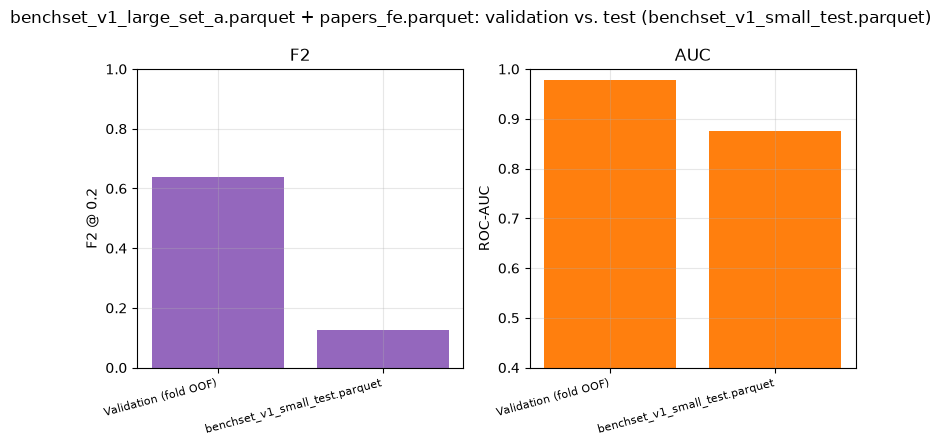

In [9]:
comparison_rows = {
    "Validation (fold OOF)": {
        "auc": meta_oof_df["auc"].mean(), "recall": meta_oof_df["recall"].mean(),
        "precision": meta_oof_df["precision"].mean(), "f2_at_threshold": meta_oof_df["f2_at_threshold"].mean(),
        "n": len(y_validation), "pos_rate": float(y_validation.mean()),
    },
    result["test_filename"]: {
        "auc": test["auc"], "recall": test["recall"], "precision": test["precision"],
        "f2_at_threshold": test["f2_at_threshold"], "n": test["n"], "pos_rate": test["pos_rate"],
    },
}
comparison_table = pd.DataFrame(comparison_rows).T.round(3)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
labels = list(comparison_table.index)
axes[0].bar(range(len(labels)), comparison_table["f2_at_threshold"], color="tab:purple")
axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
axes[0].set_ylabel(f"F2 @ {DECISION_THRESHOLD}"); axes[0].set_title("F2"); axes[0].set_ylim(0, 1.0)

axes[1].bar(range(len(labels)), comparison_table["auc"], color="tab:orange")
axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(labels, rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("ROC-AUC"); axes[1].set_title("AUC"); axes[1].set_ylim(0.4, 1.0)

fig.suptitle(f"{TRAIN_FILE} + papers_fe.parquet: validation vs. test ({result['test_filename']})")
plt.tight_layout()
plt.show()


## 8. Hard findings

Auto-generated from this run's own numbers (not hand-written), so they can't drift out of sync
with whatever this notebook actually measured.


In [10]:
print("HARD FINDINGS - generated from this run's own results\n")

stack_gap = meta_oof_row["auc"] - best_branch_auc
print(f"1. Stacking on this combined corpus: meta-learner OOF AUC {meta_oof_row['auc']:.3f} vs. best single "
      f"branch {best_branch_auc:.3f} ({'a real lift' if stack_gap > 0.01 else 'essentially tied'}, "
      f"{stack_gap:+.3f}).")

thr_res = validation_results["Ensemble @0.5 vs. Ensemble @frozen threshold"]
threshold_verdict = ("the frozen threshold still helps here" if thr_res["f2_diff"] > 0
                     else "the frozen threshold does NOT help, and may be actively hurting F2, on this combined pool")
print(f"\n2. F2 @0.5 vs. @{DECISION_THRESHOLD} on the validation OOF differs by "
      f"{thr_res['f2_diff']:+.4f} (p={thr_res['f2_p_value']:.4f}, "
      f"{'significant' if thr_res['f2_p_value'] < ALPHA else 'NOT significant'}) - {threshold_verdict}.")

logreg_res = validation_results["Ensemble vs. LogReg branch alone"]
cb_res = validation_results["Ensemble vs. CatBoost branch alone"]
print(f"\n3. On the validation OOF, AUC-wise, is the ensemble a better ranker than either base branch alone? "
      f"vs. LogReg: {logreg_res['auc_diff']:+.4f} (p={logreg_res['auc_p_value']:.4f}); "
      f"vs. CatBoost: {cb_res['auc_diff']:+.4f} (p={cb_res['auc_p_value']:.4f}).")

val_auc, val_f2 = meta_oof_df["auc"].mean(), meta_oof_df["f2_at_threshold"].mean()
print(f"\n4. Validation -> test gap (descriptive, not a significance-tested claim - see §7's markdown): "
      f"AUC {val_auc:.3f} -> {test['auc']:.3f} (gap {val_auc - test['auc']:+.3f}); "
      f"F2@threshold {val_f2:.3f} -> {test['f2_at_threshold']:.3f} (gap {val_f2 - test['f2_at_threshold']:+.3f}).")

print(f"\n5. Precision and recall together at the frozen threshold - read side by side, not F2 alone: "
      f"validation precision={meta_oof_df['precision'].mean():.3f} recall={meta_oof_df['recall'].mean():.3f}; "
      f"test precision={test['precision']:.3f} recall={test['recall']:.3f}, recall@20%={test['recall_at_20pct']:.3f}.")


HARD FINDINGS - generated from this run's own results

1. Stacking on this combined corpus: meta-learner OOF AUC 0.978 vs. best single branch 0.978 (essentially tied, +0.000).

2. F2 @0.5 vs. @0.2 on the validation OOF differs by +0.0595 (p=0.0000, significant) - the frozen threshold still helps here.

3. On the validation OOF, AUC-wise, is the ensemble a better ranker than either base branch alone? vs. LogReg: +0.0151 (p=0.0000); vs. CatBoost: +0.0019 (p=0.0000).

4. Validation -> test gap (descriptive, not a significance-tested claim - see §7's markdown): AUC 0.978 -> 0.875 (gap +0.104); F2@threshold 0.638 -> 0.125 (gap +0.513).

5. Precision and recall together at the frozen threshold - read side by side, not F2 alone: validation precision=0.272 recall=0.962; test precision=0.028 recall=0.916, recall@20%=0.770.


## 9. Scope & limitations

- **No hyperparameter search happened in this notebook, by design** — every value in
  `RF_PARAMS`/`CB_PARAMS`/`META_C`/`DECISION_THRESHOLD` was tuned against `papers_fe.parquet`'s
  pooled split in `08_ensemble_pooled.ipynb`, not against this combined pool or
  `benchset_v1_small_test.parquet`.
- **No holdout in this design, by explicit instruction** — `validation` is fold-level
  out-of-fold performance on the same combined pool the final model is refit on, not an
  untouched slice. It answers "how well-calibrated is this model to its own training
  distribution," not "how does it do on rows it has genuinely never seen from the SAME
  collections." `benchset_v1_small_test.parquet` (§6/§7) is the only surface this model has
  truly never touched in any form.
- **§5's hypothesis tests run on cross-fitted validation predictions, not a held-out surface**
  — leakage-safe for the same reason `validation_rows` itself is safe (each row's prediction
  comes from a fold that excluded it), but these rows still come from the same pool whose
  distribution the model was fit to reproduce, unlike a genuinely external test.
- **`papers_fe.parquet` is training data here, not a test surface** — a deliberate design
  choice for this notebook (see the intro's "Training-set design").
- **Feature columns are the common intersection across the four parquet files this project's
  benchset_v1 work reads**, not `08_ensemble_pooled.ipynb`'s exact list — see
  `scripts/modal_benchset_v1_ensemble.py`'s module docstring.
- **papers_fe is a small minority of the combined pool by row count** (§2's composition table)
  — its influence on the fitted model is correspondingly limited; this design tests whether
  folding it in helps at all, not a 50/50 blend.
- **This notebook and `sf_ensemble_benchset_v1_large_set_b_plus_papers_fe.ipynb` are not compared against each other** — each trains an
  entirely separate ensemble on a different combined pool. Doing so would need a further,
  explicit design decision that hasn't been made.
- **Only one random seed, one set of folds.** `RANDOM_STATE=0` throughout, matching every
  other notebook in this project's main line.
- **Modal cost.** The one cell in §1 that can trigger a fresh fit spends real Modal compute
  credits — `CACHE_PATH` exists specifically so this notebook can be re-read, re-plotted, and
  re-analyzed afterward without re-spending them.